#Deep Leakage from Gradients: Guia Completo de Implementação

##Visão Geral do Projeto

O Deep Leakage from Gradients é uma técnica de reconstrução de imagens que explora uma vulnerabilidade crítica em aprendizado federado. A pesquisa demonstra que é possível recuperar dados privados (imagens) a partir dos gradientes compartilhados durante o treinamento de redes neurais, sem acesso direto aos dados originais. Este documento fornece explicações detalhadas de cada célula do notebook, sugestões para processamento em batch e integração de imagens personalizadas.



##Importação de Bibliotecas e Configuração Inicial

In [ ]:
%matplotlib inline

import numpy as np
from pprint import pprint

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import torchvision
from torchvision import models, datasets, transforms
torch.manual_seed(50)
from random import randint

print(torch.__version__, torchvision.__version__)

2.10.0+cu128 0.25.0+cu128


In [ ]:
# Modificação para suportar batch de imagens
BATCH_SIZE = 1  # Número de imagens a processar simultaneamente
SEED = 50
torch.manual_seed(SEED)

# Você pode variar o seed para diferentes comportamentos aleatórios
# torch.manual_seed(42)  # Seed alternativo para experimentos

## Carregamento de Dataset e Funções Auxiliares

In [ ]:
dst = datasets.CIFAR100("~/.torch", download=True)
tp = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor()
])
tt = transforms.ToPILImage()

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
print("Running on %s" % device)

def label_to_onehot(target, num_classes=100):
    target = torch.unsqueeze(target, 1)
    onehot_target = torch.zeros(target.size(0), num_classes, device=target.device)
    onehot_target.scatter_(1, target, 1)
    return onehot_target

def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

100%|██████████| 169M/169M [00:04<00:00, 39.1MB/s]


Running on cuda


Carregamento do Dataset CIFAR-100

• Datasets: CIFAR100()

Pipeline de Transformação de Imagens

O objeto tp (transforms pipeline) realiza três operações sequenciais:

1. transforms.Resize(32): Redimensiona a imagem para 32×32 pixels

2. transforms.CenterCrop(32): Recorta a imagem do centro, removendo bordas.

3. transforms.ToTensor(): Converte a imagem PIL para tensor PyTorch, normalizando valores de pixel de [0] [255] para [0] [1].

O objeto tt (transforms to PIL) realiza a operação inversa: converte tensores PyTorch de volta para imagens PIL, permitindo visualização.

Função cross_entropy_for_oneho

Calcula a entropia cruzada manualmente para rótulos one-hot

Função label_to_onehot

Converte um rótulo inteiro em one-hot encoding






Pontos Editáveis para Batches e Imagens Personalizadas

Para usar seu próprio dataset em vez de CIFAR-100:



In [ ]:
# Opção 1: Usar CIFAR-10 (10 classes em vez de 100)
dst = datasets.CIFAR10("~/.torch", download=True)
num_classes = 100


100%|██████████| 170M/170M [00:05<00:00, 29.5MB/s]


## Definição da Arquitetura de Rede Neural

A classe LeNet define uma rede convolucional com a seguinte estrutura

| Camada | Entrada | Saída | Parâmetros |
| --- | --- | --- | --- |
| Conv2d | 3×32×32 | 12×16×16 | kernel=5, stride=2 |
| Sigmoid | 12×16×16 | 12×16×16 | - |
| Conv2d | 12×16×16 | 12×8×8 | kernel=5, stride=2 |
| Sigmoid | 12×8×8 | 12×8×8 | - |
| Conv2d | 12×8×8 | 12×8×8 | kernel=5, stride=1 |
| Sigmoid | 12×8×8 | 12×8×8 | - |
| Conv2d | 12×8×8 | 12×8×8 | kernel=5, stride=1 |
| Sigmoid | 12×8×8 | 12×8×8 | - |
| Flatten | 12×8×8 | 768 | - |
| Linear | 768 | 100 | - |

### Explicação das camadas convolucionais:



in_channels=3: Imagens RGB têm 3 canais


out_channels=12: Produz 12 mapas de características


kernel_size=5: Filtro 5×5


padding=5//2=2: Adiciona padding para manter tamanho


stride=2: Desloca o filtro 2 pixels, reduzindo dimensionalidade




nn.Sigmoid: Função de ativação que comprime valores para [0] [1]. Escolha deliberada (em vez de ReLU) para facilitar reconstrução.



In [ ]:
def weights_init(m):
    if hasattr(m, "weight"):
        m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, "bias"):
        m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
        )


        self.fc = nn.Sequential(
            nn.Linear(768, 100)
        )

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        # print(out.size())
        out = self.fc(out)
        return out

net = LeNet().to(device)

net.apply(weights_init)
criterion = cross_entropy_for_onehot


# # Trocar Sigmoid por ReLU (mais rápido, menos suave)
# act = nn.ReLU

# # Trocar por Tanh (similar ao Sigmoid)
# act = nn.Tanh

# # Trocar por GELU (mais moderno)
# act = nn.GELU

## Carregamento de Imagem Ground Truth e Cálculo de Gradientes

Esta célula simula o cenário de aprendizado federado onde um cliente honesto compartilha seus gradientes com um servidor ou outro cliente malicioso.

GT label is 2. 
Onehot label is 2.


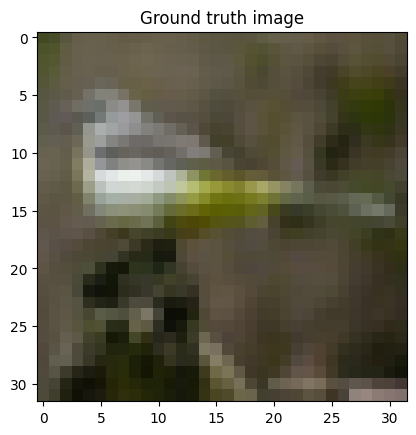

In [ ]:
######### honest partipant #########
img_index = randint(0,99)
gt_data = tp(dst[img_index][0]).to(device)
gt_data = gt_data.view(1, *gt_data.size())
gt_label = torch.Tensor([dst[img_index][1]]).long().to(device)
gt_label = gt_label.view(1, )
gt_onehot_label = label_to_onehot(gt_label, num_classes=100)

plt.imshow(tt(gt_data[0].cpu()))
plt.title("Ground truth image")
print("GT label is %d." % gt_label.item(), "\nOnehot label is %d." % torch.argmax(gt_onehot_label, dim=-1).item())

# compute original gradient
out = net(gt_data)  # Forward pass: [1, 100]
y = criterion(out, gt_onehot_label) # Loss escalar
dy_dx = torch.autograd.grad(y, net.parameters())


# share the gradients with other clients
original_dy_dx = list((_.detach().clone() for _ in dy_dx))

Este é o passo crítico do ataque:

1. Forward pass: Rede processa imagem real, produzindo logits

2. Cálculo de loss: Compara logits com rótulo real

3. Backward pass: Calcula gradientes de loss em relação a TODOS os parâmetros da rede

O gradiente $\frac{\partial L}{\partial w}$ contém informações sobre a imagem original, porque a rede foi treinada nela.



## Inicialização de Dados Dummy

Text(0.5, 1.0, 'Dummy data')

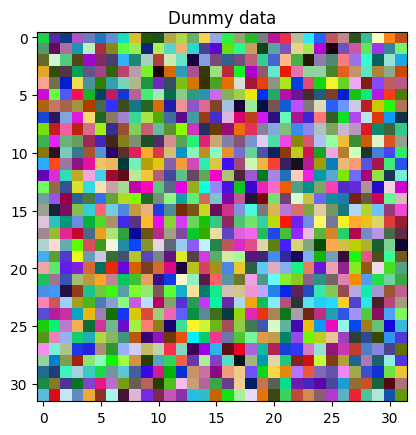

In [ ]:
# generate dummy data and label
dummy_data = torch.randn(gt_data.size()).to(device).requires_grad_(True)
dummy_label = torch.randn(gt_onehot_label.size()).to(device).requires_grad_(True)

plt.imshow(tt(dummy_data[0].cpu()))
plt.title("Dummy data")
#print("Dummy label is %d." % torch.argmax(dummy_label, dim=-1).item())

## Otimização Iterativa (Núcleo do Ataque)

Aqui ocorre o ataque de reconstrução de imagem através da otimização de gradientes.

In [ ]:
optimizer = torch.optim.LBFGS([dummy_data, dummy_label] )

history = []
for iters in range(300):
    def closure():
        optimizer.zero_grad()

        #PASSO 1
        pred = net(dummy_data)
        dummy_onehot_label = F.softmax(dummy_label, dim=-1)
        dummy_loss = criterion(pred, dummy_onehot_label) # TODO: fix the gt_label to dummy_label in both code and slides.

        #PASSO 2

        dummy_dy_dx = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        #PASSO 3
        grad_diff = 0
        grad_count = 0
        for gx, gy in zip(dummy_dy_dx, original_dy_dx): # TODO: fix the variablas here

        #PASSO 4
            grad_diff += ((gx - gy) ** 2).sum()
            grad_count += gx.nelement()
        # grad_diff = grad_diff / grad_count * 1000
        grad_diff.backward()

        return grad_diff

    optimizer.step(closure)
    if iters % 10 == 0:
        current_loss = closure()
        print(iters, "%.4f" % current_loss.item())
    history.append(tt(dummy_data[0].cpu()))

0 22.0616
10 0.4480
20 0.1122
30 0.0321
40 0.0087
50 0.0024
60 0.0009
70 0.0004
80 0.0002
90 0.0001
100 0.0000
110 0.0000
120 0.0000
130 0.0000
140 0.0000
150 0.0000
160 0.0000
170 0.0000
180 0.0000
190 0.0000
200 0.0000
210 0.0000
220 0.0000
230 0.0000
240 0.0000
250 0.0000
260 0.0000
270 0.0000
280 0.0000
290 0.0000


**Passo 1:** Forward Pass com Dados Dummy

**Passo 2:** Calcular Gradientes Dummy
Calcula gradientes de loss em relação aos parâmetros da rede

create_graph=True: Permite calcular gradientes de gradientes

**Passo 3:** Comparar Gradientes
Calcula a diferença quadrática entre:

•
gx: Gradientes calculados com dados dummy

•
gy: Gradientes reais (compartilhados no cenário federado)

**Passo 4:** Backpropagation e Atualização




## Visualização de Progresso

Dummy label is 2.


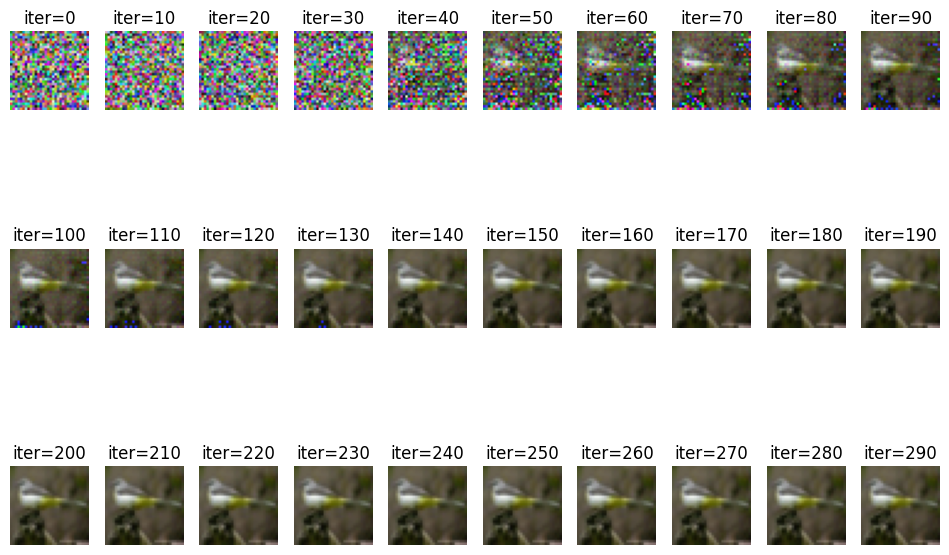

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(30):
  plt.subplot(3, 10, i + 1)
  plt.imshow(history[i * 10])
  plt.title("iter=%d" % (i * 10))
  plt.axis('off')
print("Dummy label is %d." % torch.argmax(dummy_label, dim=-1).item())